# 강의 연습문제

### Step0. 데이터 불러오기

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ortools.linear_solver import pywraplp

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (8, 5)

# 데이터 불러오기
sales = pd.read_csv('./03week_데이터_배포/sales_log.csv', parse_dates=['date'])
prod = pd.read_csv('./03week_데이터_배포/production_log.csv', parse_dates=['date'])
res = pd.read_csv('./03week_데이터_배포/resource_today.csv')

print("=== 판매 기록 ===")
print(sales.head())
print("\n=== 생산 기록 ===")    
print(prod.head())


=== 판매 기록 ===
        date product  quantity  price
0 2024-01-01       A        87   3488
1 2024-01-01       B        47   4921
2 2024-01-02       A        84   3449
3 2024-01-02       B        65   5143
4 2024-01-03       A        72   3576

=== 생산 기록 ===
        date product  quantity  oven_hours  material_kg  total_cost
0 2024-01-01       A        65       32.76        20.94    159821.0
1 2024-01-01       B        56       44.82        27.02    239111.0
2 2024-01-02       A        71       34.30        21.37    175873.0
3 2024-01-02       B        46       38.12        24.59    202611.0
4 2024-01-03       A        91       41.60        27.15    216742.0


### Step1. 수요 파라미터 추정 - D_A, D_B

1.1 데이터 확인

기초 통계:
product      A      B
count     60.0   60.0
mean      80.5   51.8
std       18.3   20.2
min       40.0   17.0
25%       69.0   37.8
50%       80.5   49.0
75%       90.2   61.2
max      136.0  124.0


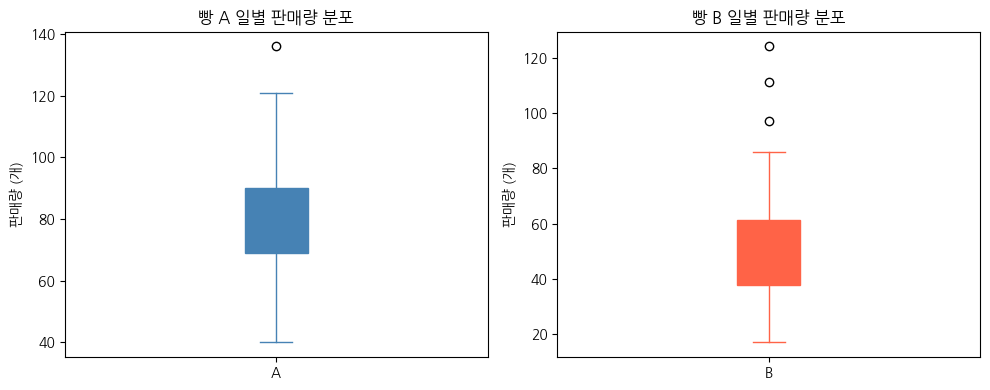

In [112]:
# 일별 제품별 판매량 집계
daily = (sales.groupby(['date', 'product'])['quantity']
         .sum()
         .unstack())

print("기초 통계:")
print(daily.describe().round(1))

import platform

if platform.system() =='Windows':
    plt.rcParams['font.family'] = 'NanumGothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# 박스플롯으로 분포 확인
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, color in zip(axes, ['A', 'B'], ['steelblue', 'tomato']):
    daily[col].plot(kind='box', ax=ax, color=color, patch_artist=True)
    ax.set_title(f'빵 {col} 일별 판매량 분포')
    ax.set_ylabel('판매량 (개)')

plt.tight_layout()
plt.show()

1.2 이상치 제거 -> Q1 - 1.5*(Q3-Q1) 이하 또는 Q1 + 1.5 * (Q3-Q1) 이상 제거  
1.3 상한치 -> 평균? 75분위(Q3)?

In [113]:
# 이상치 제거(IQR 방법)
def remove_outliers(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    return s[(s >= Q1 - 1.5 * (Q3 - Q1)) & (s <= Q3 + 1.5 * (Q3 - Q1))]

daily_clean = daily.apply(remove_outliers)

# 수요 파라미터: 75분위 사용 (재고 부족 방지)
D = daily_clean.quantile(0.75)
print("\n 평균 또는 75분위?")
print(f" 평균: A={daily_clean['A'].mean():.0f}, B={daily_clean['B'].mean():.0f}")
print(f" 75%: A={D['A']:.0f}, B={D['B']:.0f} <- 더 보수적, 기회 손실 감소")


 평균 또는 75분위?
 평균: A=80, B=49
 75%: A=90, B=61 <- 더 보수적, 기회 손실 감소


### Step2. 이익 파라미터 추출 - P_A, P_B

2.1 판매가(평균)  

In [6]:
# 판매가 평균 추출
unit_price = sales.groupby('product')['price'].mean()
print("평균 판매가")
print(unit_price.round(0))

평균 판매가
product
A    3506.0
B    5025.0
Name: price, dtype: float64


2.2 회귀분석으로 단위 변동비 추출: 총원가 = 고정비 + 변동비 * 생산량  
- 총 원가 = 고정비 + 변동비 * 생산량 -> 회귀분석으로 고정비(절편)와 변동비(기울기) 계산

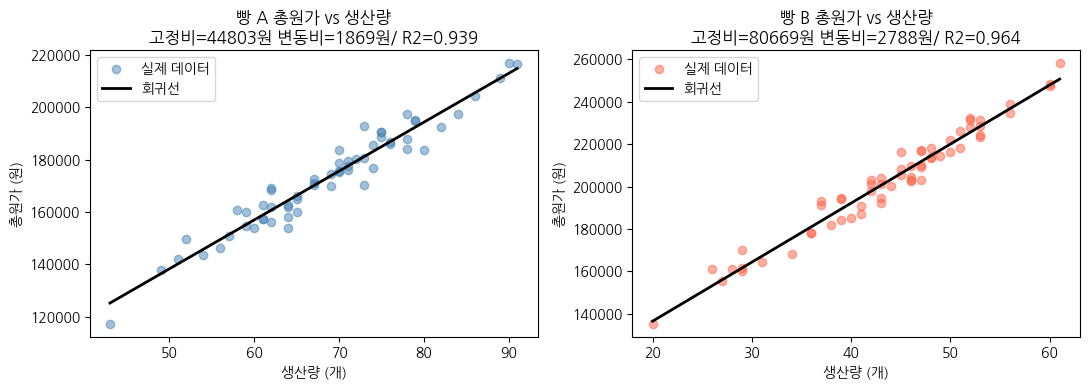


단위 변동비 (회귀 기울기)
빵 A: 1869원
빵 B: 2788원


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
unit_vc = {}

for ax, pid, color in zip(axes, ['A', 'B'], ['steelblue', 'tomato']):
    grp = prod[prod['product'] == pid]
    X = sm.add_constant(grp['quantity'])
    model = sm.OLS(grp['total_cost'], X).fit() # 회귀분석

    fixed_cost = model.params['const']
    var_cost = model.params['quantity'] # 단위 변동비
    unit_vc[pid] = var_cost

    # 산점도 + 회귀선
    ax.scatter(grp['quantity'], grp['total_cost'], alpha=0.5, color=color, label='실제 데이터')
    x_line = np.linspace(grp['quantity'].min(), grp['quantity'].max(), 100)
    ax.plot(x_line, model.params['const'] + model.params['quantity'] * x_line, 
            color='black', linewidth=2, label='회귀선')
    ax.set_title(f'빵 {pid} 총원가 vs 생산량\n고정비={fixed_cost:.0f}원 변동비={var_cost:.0f}원/ R2={model.rsquared:.3f}')
    ax.set_xlabel('생산량 (개)'); ax.set_ylabel('총원가 (원)')
    ax.legend()

plt.tight_layout()
plt.show()

print("\n단위 변동비 (회귀 기울기)")
for k, v in unit_vc.items():
    print(f"빵 {k}: {v:.0f}원")  

2.3 단위 이익 = 판매가(편균) - 단위 변동비 -> 고정비는 생산량과 무관

In [9]:
# 단위 이익 계산
p = {pid: unit_price[pid] - unit_vc[pid] for pid in ['A', 'B']}
print("단위 이익 p:")
for k, v in p.items():
    print(f"빵 {k}: {unit_price[k]:.0f}원(판매가) - {unit_vc[k]:.0f}원(변동비) = {v:.0f}원")

단위 이익 p:
빵 A: 3506원(판매가) - 1869원(변동비) = 1637원)
빵 B: 5025원(판매가) - 2788원(변동비) = 2236원)


### Step3. 자원 파라미터 추출 - a, m, CAP, MAT

- 단위당 오븐 시간(a) & 재료 사용량(m) - 평균값 활용 (production_log.csv)

In [10]:
# 단위당 오븐 시간 & 재료 사용량 (생산 로그 평균)
resource_params = (prod
                   .groupby('product')
                   .apply(lambda x: pd.Series({
                       'a (오븐시간/개)': x['oven_hours'].sum() / x['quantity'].sum(),
                       'm (재료kg/개)': x['material_kg'].sum() / x['quantity'].sum()
                   })))

print(resource_params.round(3))

a = resource_params['a (오븐시간/개)'].to_dict()
m = resource_params['m (재료kg/개)'].to_dict()

# 오늘 가용 자원
CAP = res.loc[0, 'available_oven_hours']
MAT = res.loc[0, 'available_material_kg']
print(f"\n오늘 가용 오븐: {CAP}시간")
print(f"오늘 가용 재료: {MAT}kg")

         a (오븐시간/개)  m (재료kg/개)
product                        
A             0.496       0.301
B             0.804       0.502

오늘 가용 오븐: 80시간
오늘 가용 재료: 50kg


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26796\3045341672.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


### STEP 4. Parameter Summary

In [11]:
params = pd.DataFrame({
    '파라미터': ['p (단위 이익, 원)', 'a (오븐시간/개)', 'm (재료kg/개)', 'D (수요상한, 개)'],
    '빵 A': [round(p['A'], 0), round(a['A'], 3), round(m['A'], 3), round(D['A'], 0)],
    '빵 B': [round(p['B'], 0), round(a['B'], 3), round(m['B'], 3), round(D['B'], 0)],
    '추출 방법': ['판매가 평균 - 회귀 변동비', '생산로그 집계', '생산로그 집계', '판매기록 75분위']
})

print("="*60)
print("LP 투입 파라미터 Summary")
print("="*60)
print(params.to_string(index=False))
print(f"\n CAP (가용 오븐시간) = {CAP}")
print(f" MAT (가용 재료) = {MAT} kg")

LP 투입 파라미터 Summary
        파라미터      빵 A      빵 B           추출 방법
p (단위 이익, 원) 1637.000 2236.000 판매가 평균 - 회귀 변동비
  a (오븐시간/개)    0.496    0.804         생산로그 집계
  m (재료kg/개)    0.301    0.502         생산로그 집계
 D (수요상한, 개)   90.000   61.000       판매기록 75분위

 CAP (가용 오븐시간) = 80
 MAT (가용 재료) = 50 kg


In [12]:
solver = pywraplp.Solver.CreateSolver('GLOP')

# -- 변수 선언 (하한=0, 상한 = inf) --
inf = solver.infinity()
xA = solver.NumVar(0, inf, 'xA')
xB = solver.NumVar(0, inf, 'xB')

# -- 제약식 추가 --
solver.Add(a['A'] * xA + a['B'] * xB <= CAP) # 오븐 용량
solver.Add(m['A'] * xA + m['B'] * xB <= MAT) # 재료 한도
solver.Add(xA <= D['A']) # 수요 상한 A
solver.Add(xB <= D['B']) # 수요 상한 B

# -- 목적함수 (최대화) --
solver.Maximize(p['A'] * xA + p['B'] * xB)

# -- 풀이 --
status = solver.Solve()

# status 코드: 0=OPTIMAL, 1=FEASIBLE, 2=INFEASIBLE, 3=UNBOUNDED
status_map = {0: '최적해 발견', 1: '실행 가능해 발견', 2: '실행 불가능', 3: '목적함수 무한대'}
print(f"\n최적화 상태: {status_map.get(status, status)}")
print()

xA_val = xA.solution_value()
xB_val = xB.solution_value()
obj_val = solver.Objective().Value()

print(f"최적 생산량: 빵 A = {xA_val:.0f}개, 빵 B = {xB_val:.0f}개")
print(f"최대 이익: {obj_val:.0f}원")
print()
print(f"오븐 사용: {a['A']*xA_val + a['B']*xB_val:.1f}시간 / {CAP}시간")
print(f"재료 사용: {m['A']*xA_val + m['B']*xB_val:.1f}kg / {MAT}kg")


최적화 상태: 최적해 발견

최적 생산량: 빵 A = 90개, 빵 B = 44개
최대 이익: 245533원

오븐 사용: 80.0시간 / 80시간
재료 사용: 49.1kg / 50kg


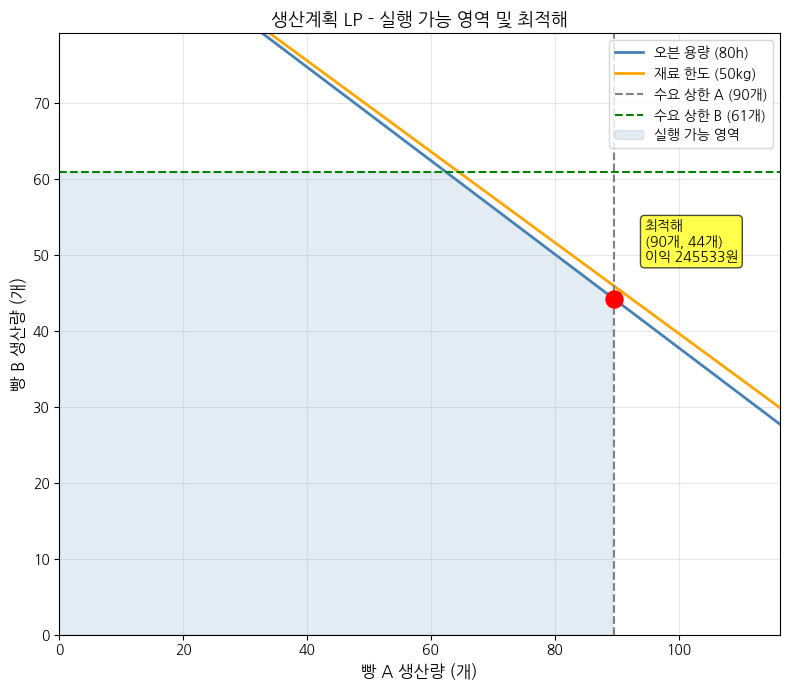

In [17]:
# 실행 가능 영역 시각화
fig, ax = plt.subplots(figsize=(8, 7))

xv = np.linspace(0, D['A'] * 1.3, 400)

# 제약 경계선
y_oven = (CAP - a['A'] * xv) / a['B']
y_mat = (MAT - m['A'] * xv) / m['B']

ax.plot(xv, np.clip(y_oven, 0, None), label=f'오븐 용량 ({CAP}h)', color='steelblue', linewidth=2)
ax.plot(xv, np.clip(y_mat, 0, None), label=f'재료 한도 ({MAT}kg)', color='orange', linewidth=2)
ax.axvline(D['A'], color='grey', linestyle='--', label=f'수요 상한 A ({D["A"]:.0f}개)')
ax.axhline(D['B'], color='green', linestyle='--', label=f'수요 상한 B ({D["B"]:.0f}개)')

# 실행 가능 영역 색칠
yf = np.minimum(np.minimum(y_oven, y_mat), D['B'])
yf = np.clip(yf, 0, None)
mask = xv <= D['A']
ax.fill_between(xv[mask], 0, yf[mask], alpha=0.15, color='steelblue', label='실행 가능 영역')

# 최적해 (OR-Tools 결과 사용)
ax.scatter(xA_val, xB_val, color='red', zorder=5, s=150)
ax.annotate(f'최적해\n({xA_val:.0f}개, {xB_val:.0f}개)\n이익 {obj_val:.0f}원', 
            xy=(xA_val, xB_val),
            xytext=(xA_val+5, xB_val+5),
            fontsize=10, 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_xlim(0, D['A'] * 1.3)
ax.set_ylim(0, D['B'] * 1.3)
ax.set_xlabel('빵 A 생산량 (개)', fontsize=12)
ax.set_ylabel('빵 B 생산량 (개)', fontsize=12)
ax.set_title('생산계획 LP - 실행 가능 영역 및 최적해', fontsize=13)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step6. 민감도 분석 - 파라미터 오차 영향
- 수요 변화(70% ~ 130%)
- 단위이익 변화(70% ~ 130%)

In [18]:
def solve_lp(p_A, p_B, D_A, D_B):
    """OR-Tools로 LP를 풀고 (최적이익, xA, xB) 반환"""
    s = pywraplp.Solver.CreateSolver('GLOP')
    inf = s.infinity()
    xA2 = s.NumVar(0, inf, 'xA')
    xB2 = s.NumVar(0, inf, 'xB')
    s.Add(a['A'] * xA2 + a['B'] * xB2 <= CAP) # 오븐 용량
    s.Add(m['A'] * xA2 + m['B'] * xB2 <= MAT) # 재료 한도
    s.Add(xA2 <= D_A) # 수요 상한 A
    s.Add(xB2 <= D_B) # 수요 상한 B
    s.Maximize(p_A * xA2 + p_B * xB2)
    s.Solve()
    return s.Objective().Value(), xA2.solution_value(), xB2.solution_value()

scales = np.linspace(0.7, 1.3, 13)

# 수요 파라미터 변화 vs 이익
profits_D = [solve_lp(p['A'], p['B'], D['A']*s, D['B']*s)[0] for s in scales]

# 단위이익 파라미터 변화 vs 이익
profits_p = [solve_lp(p['A']*s, p['B']*s, D['A'], D['B'])[0] for s in scales]

- 시각화

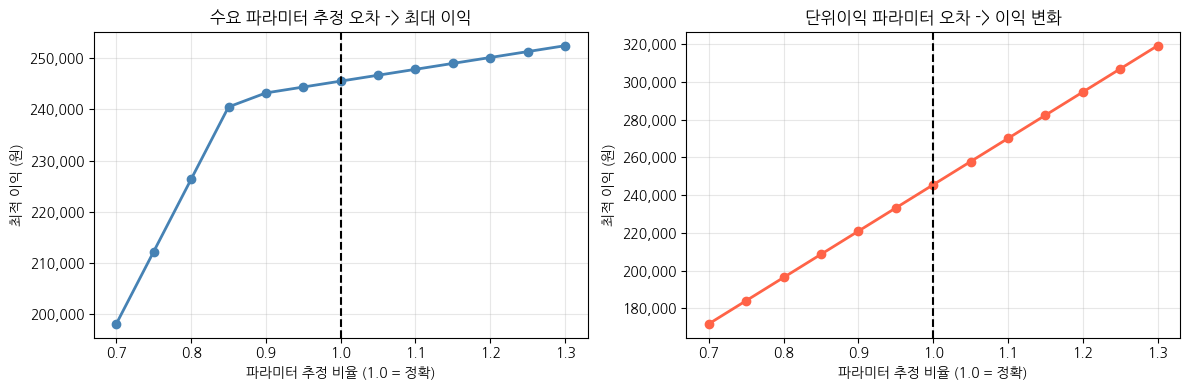

파라미터 오차가 클수록 의사결정 품질이 떨어집니다.
수요를 30% 과대 추정 시 -> 실현 이익 하락 가능성
단위이익을 30% 과소 추정 시 -> 수익성 높은 제품 과소 생산


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, profits, title, color in zip(
    axes,
    [profits_D, profits_p],
    ['수요 파라미터 추정 오차 -> 최대 이익', '단위이익 파라미터 오차 -> 이익 변화'],
    ['steelblue', 'tomato']
):
    ax.plot(scales, profits, marker='o', color=color, linewidth=2)
    ax.axvline(1.0, color='black', linestyle='--', label='기준 (오차 0%)')
    ax.set_xlabel('파라미터 추정 비율 (1.0 = 정확)')
    ax.set_ylabel('최적 이익 (원)')
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend; ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("파라미터 오차가 클수록 의사결정 품질이 떨어집니다.")
print(f"수요를 30% 과대 추정 시 -> 실현 이익 하락 가능성")
print(f"단위이익을 30% 과소 추정 시 -> 수익성 높은 제품 과소 생산")

# 실습

### Step0. 데이터 불러오기

In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ortools.linear_solver import pywraplp

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (8, 5)

# 데이터 불러오기
delivery = pd.read_csv('./03week_데이터_배포/delivery_log.csv', parse_dates=['week_start'])
contract = pd.read_csv('./03week_데이터_배포/contract_demand.csv')
res = pd.read_csv('./03week_데이터_배포/capacity_today.csv')

# delivery의 3번째 컬럼부터 값 7로 나누기
delivery.iloc[:, 2:6] = delivery.iloc[:, 2:6] / 7

# contract의 2번째 컬럼 값 7로 나누기
contract.iloc[:, 1] = contract.iloc[:, 1] / 7
contract.iloc[:, 2] = '일간 최소 처리 건수'

# delivery,contract의 6,2번째 컬럼명 변경
delivery.rename(columns={'weekly_cost': 'daily_cost'}, inplace=True)
contract.rename(columns={'weekly_min_deliveries': 'daily_min'}, inplace=True)

print("=== 8주간 배송 기록 ===")
print(delivery.head())
print("\n=== 일간 최소 처리 건수 ===")    
print(contract.head())

=== 8주간 배송 기록 ===
  week_start route  num_deliveries  driver_hours  fuel_liters     daily_cost
0 2024-01-07     A       18.428571      7.271429    56.028571  207691.714286
1 2024-01-07     B        5.000000      5.328571    46.800000  170199.285714
2 2024-01-14     A       15.714286      6.671429    46.614286  163248.857143
3 2024-01-14     B        6.285714      5.542857    54.600000  178145.285714
4 2024-01-21     A       14.142857      5.885714    41.385714  139859.428571

=== 일간 최소 처리 건수 ===
  route  daily_min         note
0     A  11.428571  일간 최소 처리 건수
1     B   3.571429  일간 최소 처리 건수


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26796\3868510183.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      18.428571
1       5.000000
2      15.714286
3       6.285714
4      14.142857
         ...    
107     8.714286
108    16.285714
109    10.285714
110    18.142857
111     1.857143
Name: num_deliveries, Length: 112, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  delivery.iloc[:, 2:6] = delivery.iloc[:, 2:6] / 7
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26796\3868510183.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0    11.428571
1     3.571429
Name: weekly_min_deliveries, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  contract.iloc[:, 1] = contract.iloc[:, 1] / 7


### Step1. 배송건수 파라미터 추정 - D_A, D_B

1.1 데이터 확인

기초 통계:
route     A     B
count  56.0  56.0
mean   17.2   5.6
std     2.0   3.0
min    12.6   1.4
25%    15.7   3.3
50%    17.3   5.5
75%    18.6   7.5
max    22.1  12.3


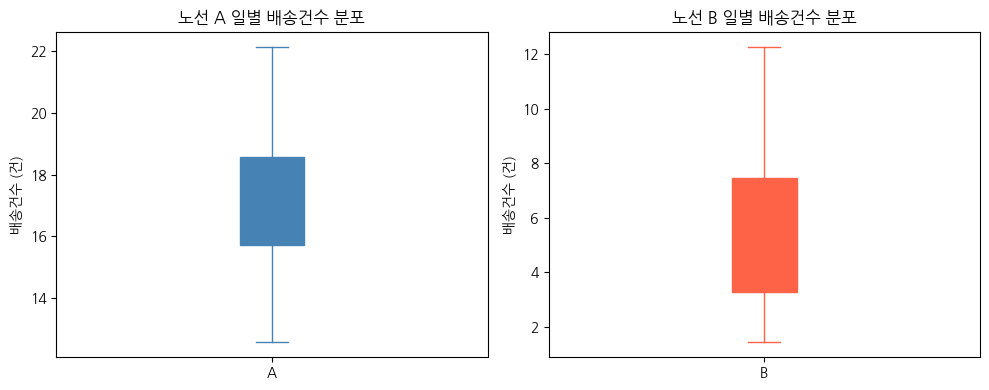

In [170]:
# 일별 배송별 배송건수 집계
daily = (delivery.groupby(['week_start', 'route'])['num_deliveries']
         .sum()
         .unstack())

print("기초 통계:")
print(daily.describe().round(1))

import platform

if platform.system() =='Windows':
    plt.rcParams['font.family'] = 'NanumGothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# 박스플롯으로 분포 확인
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, color in zip(axes, ['A', 'B'], ['steelblue', 'tomato']):
    daily[col].plot(kind='box', ax=ax, color=color, patch_artist=True)
    ax.set_title(f'노선 {col} 일별 배송건수 분포')
    ax.set_ylabel('배송건수 (건)')

plt.tight_layout()
plt.show()


1.2 일별 최소 처리량 이상 미만량 제거  
1.3 하한치 -> 일별 최소 처리량

In [171]:
# 계약서에 명시된 일별 최소 처리량 미만량 제거
# daily의 컬럼 A는 계약서의 일간 최소 처리 건수A보다 작은 값 제거,
# daily의 컬럼 B는 계약서의 일간 최소 처리 건수B보다 작은 값 제거

minA, minB = contract.set_index('route')['daily_min']
daily_clean = daily[(daily['A'] >= minA) & (daily['B'] >= minB)]

# 배송건수 파라미터: 하한값 사용 (계약서 조건 충족 보장)
D = contract.set_index('route')['daily_min']
print("\n 평균 또는 75분위?")
print(f" 평균: A={daily_clean['A'].mean():.1f}, B={daily_clean['B'].mean():.1f}")
print(f" 하한값: A={daily_clean['A'].min():.1f}, B={daily_clean['B'].min():.1f}")


 평균 또는 75분위?
 평균: A=17.1, B=7.0
 하한값: A=12.6, B=3.6


### Step2. 비용 파라미터 추출 - C_A, C_B

2.1 비용(평균)  

In [172]:
# 비용 평균 추출
unit_price = delivery.groupby('route')['daily_cost'].mean()
print("평균 비용:")
print(unit_price.round(0))

평균 비용:
route
A    180476.0
B    172674.0
Name: daily_cost, dtype: float64


2.2 회귀분석으로 단위 비용 추출: 하루 총비용 = 건별비용 * 배송량  
- 하루 총 비용 = 건별비용 * 배송량 -> 회귀분석으로 건별비용(기울기) 계산

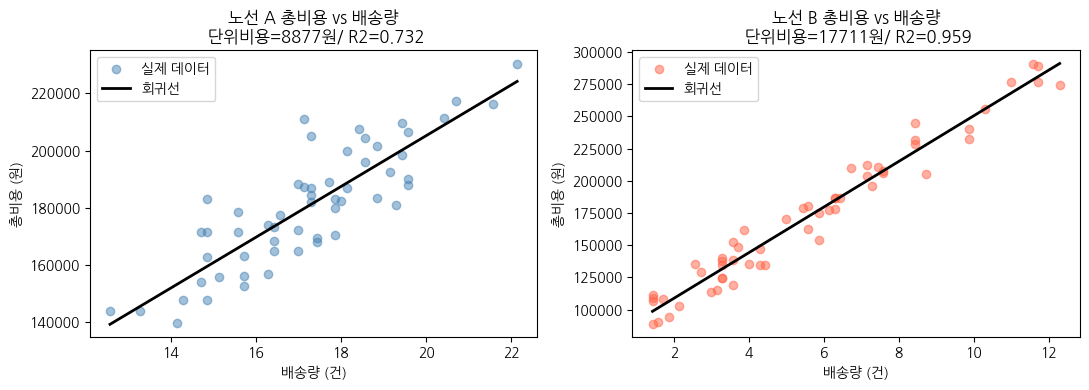


단위 비용 (회귀 기울기)
노선 A: 8877원
노선 B: 17711원


In [173]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
unit_vc = {}

for ax, pid, color in zip(axes, ['A', 'B'], ['steelblue', 'tomato']):
    grp = delivery[delivery['route'] == pid]
    X = sm.add_constant(grp['num_deliveries'])
    model = sm.OLS(grp['daily_cost'], X).fit() # 회귀분석

    fixed_cost = model.params['const']
    var_cost = model.params['num_deliveries'] # 단위 비용
    unit_vc[pid] = var_cost

    # 산점도 + 회귀선
    ax.scatter(grp['num_deliveries'], grp['daily_cost'], alpha=0.5, color=color, label='실제 데이터')
    x_line = np.linspace(grp['num_deliveries'].min(), grp['num_deliveries'].max(), 100)
    ax.plot(x_line, model.params['const'] + model.params['num_deliveries'] * x_line, 
            color='black', linewidth=2, label='회귀선')
    ax.set_title(f'노선 {pid} 총비용 vs 배송량\n 단위비용={var_cost:.0f}원/ R2={model.rsquared:.3f}')
    ax.set_xlabel('배송량 (건)'); ax.set_ylabel('총비용 (원)')
    ax.legend()

plt.tight_layout()
plt.show()

print("\n단위 비용 (회귀 기울기)")
for k, v in unit_vc.items():
    print(f"노선 {k}: {v:.0f}원")  

2.3 건당 변동 비용 = 회귀 기울기

In [174]:
# 단위 이익 계산
c = {pid: unit_vc[pid] for pid in ['A', 'B']}

### Step3. 자원 파라미터 추출 - h, f, CAP, FUEL

- 단위당 기사 시간(a) & 재료 사용량(m) - 평균값 활용

In [195]:
# 단위당 기사 시간 & 연료 사용량
# 기사들의 총 근무 시간이 오늘 가용한 기사 시간을 초과할 수 없다.
# 총 연료 소모량이 오늘 보유한 연료량을 초과할 수 없다.
# minh, minf는 각각 res의 첫열의 첫행값,두번째열의 첫행값 


resource_params = (delivery
                   .groupby('route')
                   .apply(lambda x: pd.Series({
                       'h (기사시간/건)': x['driver_hours'].sum() / x['num_deliveries'].sum(),
                       'f (연료L/건)': x['fuel_liters'].sum() / x['num_deliveries'].sum()
                   })))

print(resource_params.round(3))

h = resource_params['h (기사시간/건)'].to_dict()
f = resource_params['f (연료L/건)'].to_dict()

# 오늘 가용 자원
CAP = res.loc[0, 'available_driver_hours']
FUEL = res.loc[0, 'available_fuel_liters']
print(f"\n가용 기사 시간: {CAP}시간")
print(f"가용 연료량: {FUEL}L")

       h (기사시간/건)  f (연료L/건)
route                       
A           0.411      3.013
B           1.080      8.957

가용 기사 시간: 15시간
가용 연료량: 150L


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26796\3054319314.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


### STEP 4. Parameter Summary

In [196]:
params = pd.DataFrame({
    '파라미터': ['c (건당 변동비, 원)', 'h (기사시간/건)', 'f (연료L/건)', 'D (일최소처리, 건)'],
    '노선 A': [round(c['A'], 0), round(h['A'], 3), round(f['A'], 3), round(D['A'], 1)],
    '노선 B': [round(c['B'], 0), round(h['B'], 3), round(f['B'], 3), round(D['B'], 1)],
    '추출 방법': ['회귀분석 (기울기)', '배송 시간 평균', '연료 사용량 평균', '계약서 주간값/7']
})

print("="*60)
print("LP 투입 파라미터 Summary")
print("="*60)
print(params.to_string(index=False))
print(f"\n CAP (가용 기사시간) = {CAP}")
print(f" FUEL (가용 연료) = {FUEL} L")

LP 투입 파라미터 Summary
         파라미터     노선 A      노선 B      추출 방법
c (건당 변동비, 원) 8877.000 17711.000 회귀분석 (기울기)
   h (기사시간/건)    0.411     1.080   배송 시간 평균
    f (연료L/건)    3.013     8.957  연료 사용량 평균
 D (일최소처리, 건)   11.400     3.600  계약서 주간값/7

 CAP (가용 기사시간) = 15
 FUEL (가용 연료) = 150 L


In [209]:
solver = pywraplp.Solver.CreateSolver('GLOP')

# -- 변수 선언 (하한=0, 상한 = inf) --
inf = solver.infinity()
xA = solver.NumVar(0, inf, 'xA')
xB = solver.NumVar(0, inf, 'xB')

# -- 제약식 추가 --
solver.Add(h['A'] * xA + h['B'] * xB <= CAP) # 가용한 기사 시간
solver.Add(f['A'] * xA + f['B'] * xB <= FUEL) # 보유한 연료량
solver.Add(xA >= D['A']) # 배송 하한 A
solver.Add(xB >= D['B']) # 배송 하한 B

# -- 목적함수 (최대화) --
solver.Minimize(c['A'] * xA + c['B'] * xB)

# -- 풀이 --
status = solver.Solve()

# status 코드: 0=OPTIMAL, 1=FEASIBLE, 2=INFEASIBLE, 3=UNBOUNDED
status_map = {0: '최적해 발견', 1: '실행 가능해 발견', 2: '실행 불가능', 3: '목적함수 무한대'}
print(f"\n최적화 상태: {status_map.get(status, status)}")
print()

xA_val = xA.solution_value()
xB_val = xB.solution_value()
obj_val = solver.Objective().Value()

print(f"최적 생산량: 노선 A = {xA_val:.1f}개, 노선 B = {xB_val:.1f}개")
print(f"최소 비용: {obj_val:.0f}원")
print()
print(f" 기사 시간 사용: {h['A']*xA_val + h['B']*xB_val:.1f}시간 / {CAP}시간")
print(f" 연료 사용: {f['A']*xA_val + f['B']*xB_val:.1f}L / {FUEL}L")


최적화 상태: 최적해 발견

최적 생산량: 노선 A = 11.4개, 노선 B = 3.6개
최소 비용: 164708원

 기사 시간 사용: 8.6시간 / 15시간
 연료 사용: 66.4L / 150L


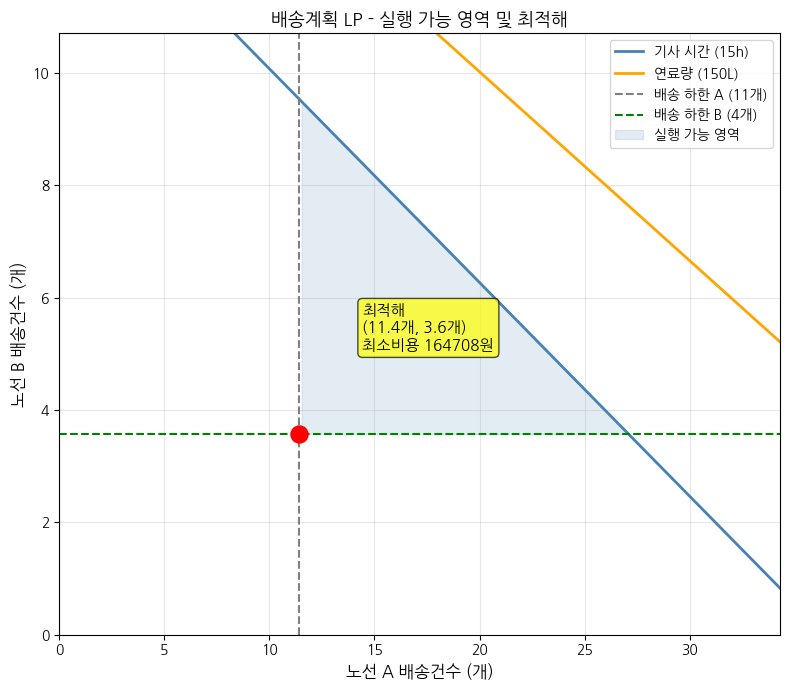

In [214]:
# 실행 가능 영역 시각화
fig, ax = plt.subplots(figsize=(8, 7))

xv = np.linspace(0, 120, 500)

# 제약 경계선
y_hour = (CAP - h['A'] * xv) / h['B']
y_fuel = (FUEL - f['A'] * xv) / f['B']

ax.plot(xv, np.clip(y_hour, 0, None), label=f'기사 시간 ({CAP}h)', color='steelblue', linewidth=2)
ax.plot(xv, np.clip(y_fuel, 0, None), label=f'연료량 ({FUEL}L)', color='orange', linewidth=2)
ax.axvline(D['A'], color='grey', linestyle='--', label=f'배송 하한 A ({D["A"]:.0f}개)')
ax.axhline(D['B'], color='green', linestyle='--', label=f'배송 하한 B ({D["B"]:.0f}개)')

# 실행 가능 영역 색칠
yf = np.minimum(y_hour, y_fuel)
yf = np.clip(yf, 0, None)
mask = (xv >= D['A']) & (yf >= D['B'])
ax.fill_between(xv[mask], D['B'], yf[mask], alpha=0.15, color='steelblue', label='실행 가능 영역')

# 최적해 (OR-Tools 결과 사용)
ax.scatter(xA_val, xB_val, color='red', zorder=5, s=150)
ax.annotate(f'최적해\n({xA_val:.1f}개, {xB_val:.1f}개)\n최소비용 {obj_val:.0f}원', 
            xy=(xA_val, xB_val),
            xytext=(xA_val+3, xB_val+1.5),
            fontsize=11, 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_xlim(0, D['A'] * 3)
ax.set_ylim(0, D['B'] * 3)
ax.set_xlabel('노선 A 배송건수 (개)', fontsize=12)
ax.set_ylabel('노선 B 배송건수 (개)', fontsize=12)
ax.set_title('배송계획 LP - 실행 가능 영역 및 최적해', fontsize=13)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step6. 민감도 분석 - 파라미터 오차 영향
- 수요 변화(70% ~ 130%)
- 단위이익 변화(70% ~ 130%)

In [236]:
def solve_lp(c_A, c_B, D_A, D_B):
    """OR-Tools로 LP를 풀고 (최적이익, xA, xB) 반환"""
    s = pywraplp.Solver.CreateSolver('GLOP')
    inf = s.infinity()
    xA2 = s.NumVar(0, inf, 'xA')
    xB2 = s.NumVar(0, inf, 'xB')
    s.Add(h['A'] * xA2 + h['B'] * xB2 <= CAP) # 시간 용량
    s.Add(f['A'] * xA2 + f['B'] * xB2 <= FUEL) # 연료 한도
    s.Add(xA2 >= D_A) # 배송 하한 A
    s.Add(xB2 >= D_B) # 배송 하한 B
    s.Minimize(c_A * xA2 + c_B * xB2)
    s.Solve()
    return s.Objective().Value(), xA2.solution_value(), xB2.solution_value()

scales = np.linspace(0.7, 1.3, 13)

# 배송 파라미터 변화 vs 이익
profits_D = [solve_lp(c['A'], c['B'], D['A']*s, D['B']*s)[0] for s in scales]

# 단위비용 파라미터 변화 vs 이익
profits_c = [solve_lp(c['A']*s, c['B']*s, D['A'], D['B'])[0] for s in scales]

- 시각화

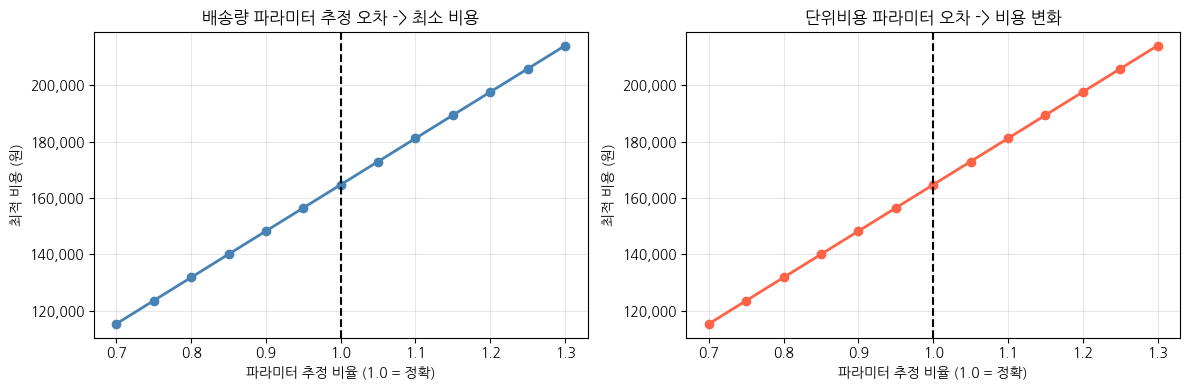

파라미터 오차가 클수록 의사결정 품질이 떨어집니다.
배송량을 30% 과대 추정 시 -> 실현 비용 증가 가능성
단위비용을 30% 과소 추정 시 -> 비용이 높은 제품 과소 생산


In [237]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, profits, title, color in zip(
    axes,
    [profits_D, profits_c],
    ['배송량 파라미터 추정 오차 -> 최소 비용', '단위비용 파라미터 오차 -> 비용 변화'],
    ['steelblue', 'tomato']
):
    ax.plot(scales, profits, marker='o', color=color, linewidth=2)
    ax.axvline(1.0, color='black', linestyle='--', label='기준 (오차 0%)')
    ax.set_xlabel('파라미터 추정 비율 (1.0 = 정확)')
    ax.set_ylabel('최적 비용 (원)')
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend; ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("파라미터 오차가 클수록 의사결정 품질이 떨어집니다.")
print(f"배송량을 30% 과대 추정 시 -> 실현 비용 증가 가능성")
print(f"단위비용을 30% 과소 추정 시 -> 비용이 높은 제품 과소 생산")